In [1]:
import os
import joblib
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report
from transformers import AutoTokenizer
from optimum.onnxruntime import ORTModelForSequenceClassification, ORTQuantizer
from optimum.onnxruntime.configuration import AutoQuantizationConfig

ENCODER_PATH = Path("../../label_encoder_model_a.joblib")
ONNX_A_PATH = Path("../../onnx_models/model_A_quantized")
TEST_DATA_PATH = Path("../data/processed/gold_test_holdout.csv")

test_df = pd.read_csv(TEST_DATA_PATH)
label2id = joblib.load(ENCODER_PATH)
all_labels = list(label2id.keys())

# загрузка квантизированной модели и токенизатора
quantized_model = ORTModelForSequenceClassification.from_pretrained(ONNX_A_PATH)
tokenizer = AutoTokenizer.from_pretrained(ONNX_A_PATH)

y_true = test_df['label'].map(label2id).values
predictions = []

for text in tqdm(test_df['text'].tolist()):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    outputs = quantized_model(**inputs)
    
    logits = outputs.logits
    if hasattr(logits, 'detach'):
        logits = logits.detach().numpy()
        
    predictions.append(np.argmax(logits))

new_f1 = f1_score(y_true, predictions, average='macro')
original_f1 = 0.81

print("\n" + "="*40)
print(f"Итоговый отчет для диплома:")
print(f"F1-score Первой версии квантизированной модели Модели А: {original_f1:.4f}")
print(f"F1-score дообученной КВАНТИЗИРОВАННОЙ Модели А: {new_f1:.4f}")

f1_drop = (original_f1 - new_f1) / original_f1 * 100
print(f"Падение качества: {f1_drop:.2f}%")

if f1_drop > 2:
    print("Падение качества более 2%.")
else:
    print("Потери минимальны!")
print("="*40)

all_label_ids = sorted(label2id.values())

print("\nДетальный отчет квантизированной модели (v2):")
print(classification_report(
    y_true, 
    predictions, 
    labels=all_label_ids,       # Явно указываем все ID от 0 до 30
    target_names=all_labels,    # Имена для всех 31 классов
    zero_division=0             # Чтобы не было варнингов для классов с 0 примеров
))

W0522 15:52:22.229000 9188 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Could not find any ONNX files with standard file name model.onnx, files found: [WindowsPath('model_quantized.onnx')]. Please make sure to pass a `file_name` and/or `subfolder` argument to `from_pretrained` when loading an ONNX file with non-standard file names.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 336.90it/s]


Итоговый отчет для диплома:
F1-score Первой версии квантизированной модели Модели А: 0.8100
F1-score дообученной КВАНТИЗИРОВАННОЙ Модели А: 0.8196
Падение качества: -1.18%
Потери минимальны!

Детальный отчет квантизированной модели (v2):
                                       precision    recall  f1-score   support

               APP_API_AUTH_500_ERROR       0.75      1.00      0.86         6
         APP_CARD_AUTH_BUSINESS_ERROR       1.00      1.00      1.00         4
APP_FINBANK_FUNCTIONAL_UNAVAILABILITY       1.00      1.00      1.00         1
             APP_INTERNAL_ERROR_CODES       0.00      0.00      0.00         2
                              APP_ZOD       1.00      1.00      1.00         1
                                EMAIL       1.00      1.00      1.00         1
             INFRA_CONNECTION_REFUSED       0.00      0.00      0.00         1
                 INFRA_CPU_HIGH_USAGE       0.78      1.00      0.88         7
            INFRA_DISK_SPACE_CRITICAL       0.50 

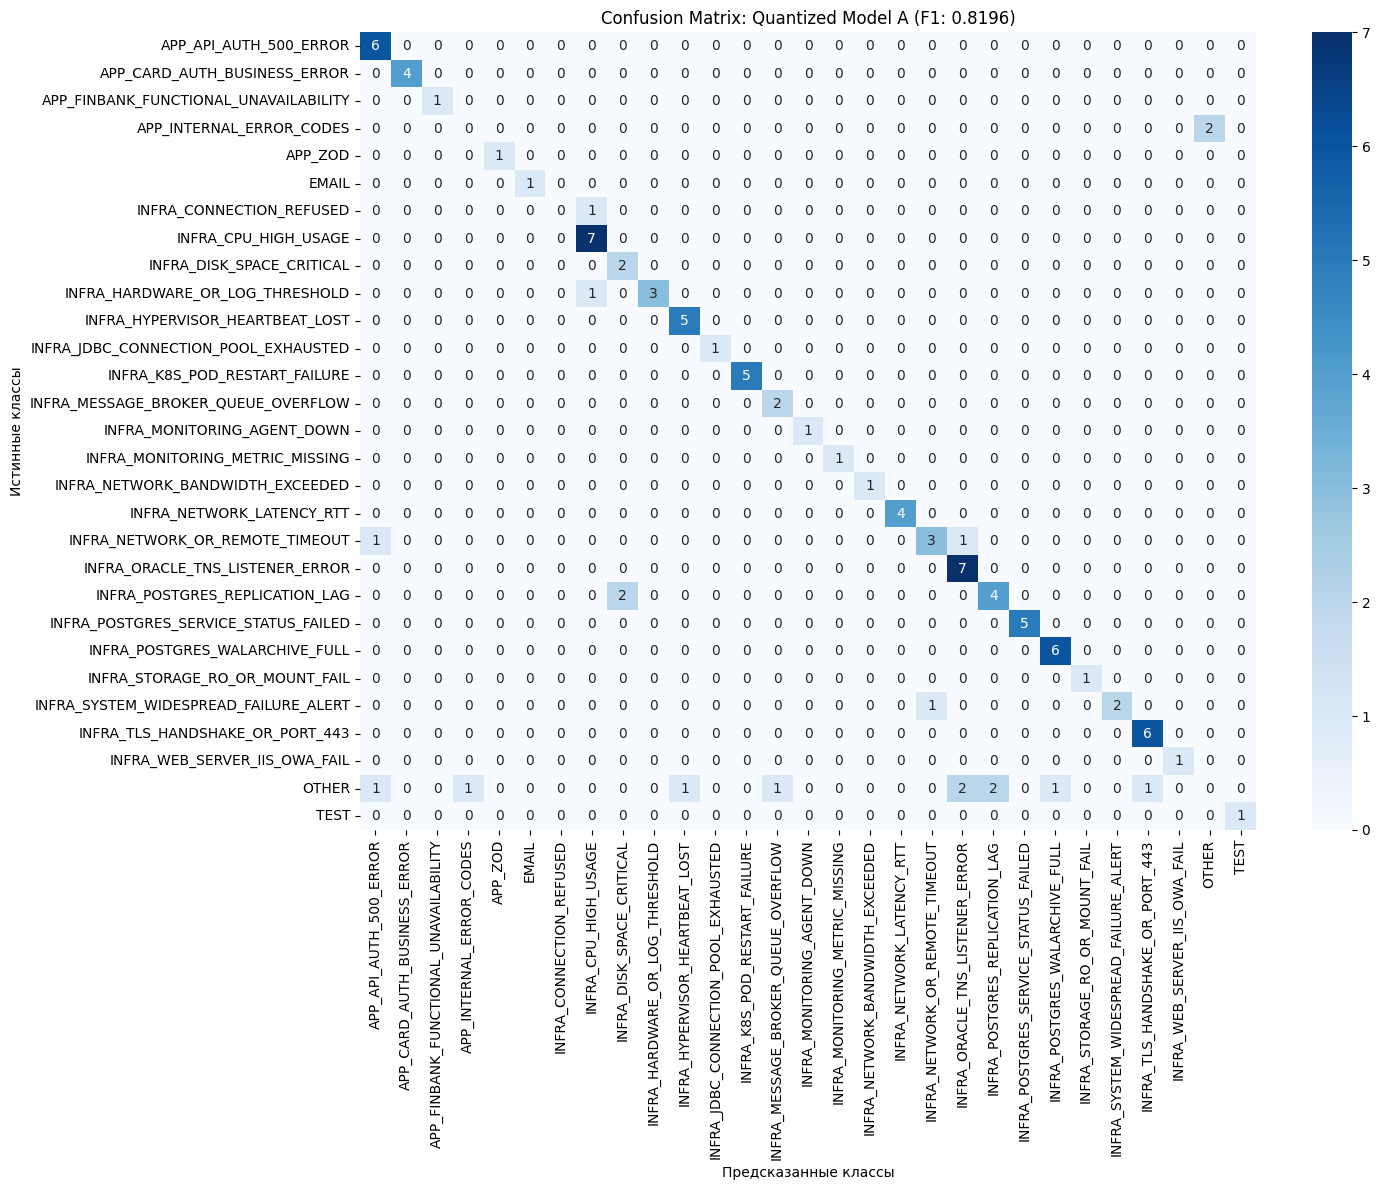


Анализ деградации:
⚠️ Класс 'APP_INTERNAL_ERROR_CODES' сильно пострадал: F1 = 0.00 (Примеров в тесте: 2.0)
⚠️ Класс 'INFRA_CONNECTION_REFUSED' сильно пострадал: F1 = 0.00 (Примеров в тесте: 1.0)
⚠️ Класс 'OTHER' сильно пострадал: F1 = 0.00 (Примеров в тесте: 10.0)


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, predictions)

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=all_labels, 
    yticklabels=all_labels
)

plt.title(f"Confusion Matrix: Quantized Model A (F1: {new_f1:.4f})")
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("confusion_matrix_quantized.png", dpi=300)
plt.show()

#
print("\nАнализ деградации:")

# output_dict=True, чтобы получить словарь, а не строку
report_dict = classification_report(
    y_true, 
    predictions, 
    labels=all_label_ids,       
    target_names=all_labels,    
    zero_division=0,
    output_dict=True 
)

for label, metrics in report_dict.items():
    # проверка, что это данные по конкретному классу, а не итоговые метрики 'accuracy' и т.д.
    if isinstance(metrics, dict) and 'f1-score' in metrics:
        if metrics['f1-score'] < 0.5:
            # только те классы, которые реально были в тесте (support > 0)
            if metrics['support'] > 0:
                print(f"⚠️ Класс '{label}' сильно пострадал: F1 = {metrics['f1-score']:.2f} (Примеров в тесте: {metrics['support']})")